In [1]:
%%capture
!pip install unsloth langchain langchain-huggingface faiss-cpu langchain-community

In [8]:
import shutil
# I unzip the zip file containing the model
shutil.unpack_archive("pharma_visiontext_model.zip", "pharma_model", "zip")

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
drive_path = '/content/drive/MyDrive/images_processed.zip'

In [9]:
# 1. Crear la carpeta que tus rutas esperan
import zipfile
target_dir = "/content/images_processed"
if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print(f"✅ Imágenes extraídas correctamente en {target_dir}")
else:
    print("❌ No se encontró el archivo ZIP en Drive. Verifica el nombre.")

✅ Imágenes extraídas correctamente en /content/images_processed


In [5]:
from unsloth import FastVisionModel
import torch
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
# I load the model
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "pharma_model",
    max_seq_length = 2048,
    load_in_4bit = True,
)

In [ ]:
FastVisionModel.for_inference(model)

In [ ]:
# I load the vector database (FAISS)
embeddings = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")

In [12]:
vector_db = FAISS.load_local("faiss_mid", embeddings, allow_dangerous_deserialization=True)

In [14]:
from PIL import Image

def pharmaceutical_question(question, image=None, k=5, critical_threshold=1.5):

    # === CASO 1: VISIÓN + TEXTO ===
    if image is not None:
        if isinstance(image, str):
            image = Image.open(image).convert("RGB")

        # --- FASE 1: VISIÓN (El modelo recupera la vista) ---
        # Usamos un prompt similar al que usaste en tu entrenamiento (dataset maestro)
        vision_messages = [
            {"role": "user", "content": [
                {"type": "image"}, # Solo indicamos el tipo
                {"type": "text", "text": "Identify the medication shown in the image. Return ONLY the name."}
            ]}
        ]

        # PASO CRÍTICO: Tokenización en dos pasos para no perder la imagen
        prompt_vision = tokenizer.apply_chat_template(vision_messages, add_generation_prompt=True, tokenize=False)
        vision_inputs = tokenizer(text=prompt_vision, images=image, return_tensors="pt", padding=True).to("cuda")

        # Usamos **vision_inputs para inyectar tanto texto como tensores de imagen
        vision_outputs = model.generate(**vision_inputs, max_new_tokens=20, temperature=0.1, use_cache=True)
        medication_raw = tokenizer.batch_decode(vision_outputs, skip_special_tokens=True)[0].split("model\n")[-1].strip()

        # Limpiamos por si el modelo responde con la frase entera con la que entrenó
        medication_name = medication_raw.replace("The medication identified in the image is ", "").replace(".", "").strip()
        print(f"👁️ [Visión] Medicamento detectado: {medication_name}")

        # --- FASE 2: BÚSQUEDA RAG INTELIGENTE ---
        search_query = f"{medication_name} {question}"
        docs_with_score = vector_db.similarity_search_with_score(search_query, k=k)
        if docs_with_score[0][1] > critical_threshold:
          print(f"⚠️ High RAG score ({docs_with_score[0][1]:.2f}).")
        docs = [doc for doc, score in docs_with_score]
        retrieved_context = "\n\n".join([doc.page_content for doc in docs])

        # --- FASE 3: RAZONAMIENTO Y RESPUESTA FINAL ---
        final_messages = [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": f"Context: {retrieved_context}\n\nInformation: The medication identified in the image is {medication_name}.\nQuestion: {question}"}
            ]}
        ]

        prompt_final = tokenizer.apply_chat_template(final_messages, add_generation_prompt=True, tokenize=False)
        final_inputs = tokenizer(text=prompt_final, images=image, return_tensors="pt", padding=True).to("cuda")

        outputs = model.generate(**final_inputs, max_new_tokens=512, temperature=0.1, use_cache=True)
        answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1].strip()

        return answer, docs

    # === CASO 2: SOLO TEXTO (Corrige el Test 1) ===
    else:
        docs_with_score = vector_db.similarity_search_with_score(question, k=k)

        if docs_with_score[0][1] > critical_threshold:
            return "The question is out of my domain, and I cannot find any related information.", []

        docs = [doc for doc, score in docs_with_score]
        retrieved_context = "\n\n".join([doc.page_content for doc in docs])

        final_messages = [
            {"role": "user", "content": [
                {"type": "text", "text": f"Context: {retrieved_context}\n\nQuestion: {question}"}
            ]}
        ]

        prompt_final = tokenizer.apply_chat_template(final_messages, add_generation_prompt=True, tokenize=False)

        # Al no haber imagen, solo pasamos el texto
        final_inputs = tokenizer(text=prompt_final, return_tensors="pt", padding=True).to("cuda")

        outputs = model.generate(**final_inputs, max_new_tokens=512, temperature=0.1, use_cache=True)
        answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1].strip()

        return answer, docs

In [15]:
# --- TEST 1: Text only (same as before) ---
user_question = "What is the composition of Aciloc 150?"

answer, sources = pharmaceutical_question(user_question)

print(f"\n--- QUESTION ---\n{user_question}")
print(f"\n--- ASSISTANT'S RESPONSE ---\n{answer}")
print("\n--- SOURCES ---")
for i, doc in enumerate(sources):
    print(f"Source {i+1}: {doc.metadata.get('source', 'Unknown')}")



--- QUESTION ---
What is the composition of Aciloc 150?

--- ASSISTANT'S RESPONSE ---
The composition of Aciloc 150 is:

*   Aceclofenac 150mg
*   Paracetamol 325mg

--- SOURCES ---
Source 1: MDI_Dataset
Source 2: MDI_Dataset
Source 3: MDI_Dataset
Source 4: MDI_Dataset
Source 5: MDI_Dataset


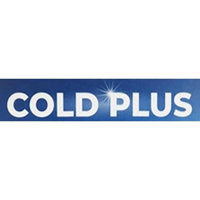

👁️ [Visión] Medicamento detectado: Cold Plus

--- QUESTION ---
What medication is shown in the image? What are its main uses?
--- IMAGE PATH ---
/content/images_processed/padded_12.jpg
🤖 --- ASSISTANT'S RESPONSE ---
Here's the information from the image:

*   **Medication:** Cold Plus tablet
*   **Main Uses:** Treatment of common cold. It relieves symptoms like blocked nose, runny nose, watery eyes, sneezing, and congestion. It helps loosen thick mucus, making it easier to cough out.

--- SOURCES ---
Source 1: MDI_Dataset
Source 2: MDI_Dataset
Source 3: MDI_Dataset
Source 4: MDI_Dataset
Source 5: MDI_Dataset


In [16]:
# --- TEST 2: Vision + Text ---
user_question = "What medication is shown in the image? What are its main uses?"
image_path = "/content/images_processed/padded_12.jpg"

img = Image.open(image_path)
display(img.resize((200, 200)))

answer, sources = pharmaceutical_question(user_question, image=image_path)


print(f"\n--- QUESTION ---\n{user_question}")
print(f"--- IMAGE PATH ---\n{image_path}")
print(f"🤖 --- ASSISTANT'S RESPONSE ---\n{answer}")
print("\n--- SOURCES ---")
for i, doc in enumerate(sources):
    print(f"Source {i+1}: {doc.metadata.get('source', 'Unknown')}")

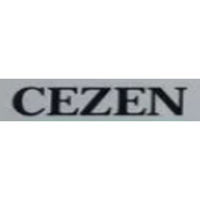

👁️ [Visión] Medicamento detectado: CEZEN

--- QUESTION ---
What medication is shown in the image?
--- IMAGE PATH ---
/content/images_processed/padded_15.png
🤖 --- ASSISTANT'S RESPONSE ---
Based on the image and the provided context, the medication shown is CEZEN.

--- SOURCES ---
Source 1: MDI_Dataset
Source 2: MDI_Dataset
Source 3: MDI_Dataset
Source 4: MDI_Dataset
Source 5: MDI_Dataset


In [18]:
# --- TEST 3: Vision ---
user_question = "What medication is shown in the image?"
image_path = "/content/images_processed/padded_15.png"

img = Image.open(image_path)
display(img.resize((200, 200)))

answer, sources = pharmaceutical_question(user_question, image=image_path)

print(f"\n--- QUESTION ---\n{user_question}")
print(f"--- IMAGE PATH ---\n{image_path}")
print(f"🤖 --- ASSISTANT'S RESPONSE ---\n{answer}")
print("\n--- SOURCES ---")
for i, doc in enumerate(sources):
    print(f"Source {i+1}: {doc.metadata.get('source', 'Unknown')}")


In [19]:
# --- TEST 4: Out-of-domain ---
user_question = "Who is Messi?"

answer, sources = pharmaceutical_question(user_question)

print(f"\n--- QUESTION ---\n{user_question}")
print(f"\n--- ASSISTANT'S RESPONSE ---\n{answer}")
print("\n--- SOURCES ---")
for i, doc in enumerate(sources):
    print(f"Source {i+1}: {doc.metadata.get('source', 'Unknown')}")



--- QUESTION ---
Who is Messi?

--- ASSISTANT'S RESPONSE ---
The question is out of my domain, and I cannot find any related information.

--- SOURCES ---
